BRAIN TUMOR IMAGE CLASSIFICATION USING CNN - PYTORCH  

In [5]:
#Mouting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torchinfo

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.8 MB/s eta 0:00:00


In [63]:
#import essential libraries
import torch
import torch.nn as nn
from torch import optim
import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,random_split


from torchinfo import summary

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pathlib
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay

import optuna

import warnings
warnings.filterwarnings('ignore')


In [62]:
#set random seeds for reproducibility
torch.manual_seed(42)


In [ ]:
#check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device:{device}")

using device:cuda


#DATASET

In [6]:
os.listdir('/content/drive/MyDrive/Brain_Tumor_Data_Set')

['Brain_Tumor', 'Healthy']

Loading Metadata(CSV file) about the Image [link text](https://)dataset




In [7]:
labels_df = pd.read_csv('/content/drive/MyDrive/Metadata_brain_tumor_dataset/Metadata_brain_tumor_dataset.csv')
print(labels_df.head().to_markdown())

|    |   Unnamed: 0 | image           | class   | format   | mode   | shape         |
|---:|-------------:|:----------------|:--------|:---------|:-------|:--------------|
|  0 |            0 | Cancer (1).jpg  | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  1 |            1 | Cancer (1).png  | tumor   | PNG      | L      | (300, 240)    |
|  2 |            2 | Cancer (1).tif  | tumor   | TIFF     | RGB    | (256, 256, 3) |
|  3 |            3 | Cancer (10).jpg | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  4 |            4 | Cancer (10).tif | tumor   | TIFF     | RGB    | (256, 256, 3) |


Exploring the metadata of the Image dataset

In [8]:
labels_df.shape

(4600, 6)

In [9]:
labels_df["class"].unique()

array(['tumor', 'normal'], dtype=object)

In [10]:
labels_df["class"].value_counts()

,count
class,
tumor,2513
normal,2087


In [11]:
labels_df["format"].unique()

array(['JPEG', 'PNG', 'TIFF'], dtype=object)

In [12]:
labels_df["format"].value_counts()

,count
format,
JPEG,4496
TIFF,86
PNG,18


In [13]:

labels_df["mode"].unique()

array(['RGB', 'L', 'RGBA', 'P'], dtype=object)

In [14]:
labels_df["mode"].value_counts()

,count
mode,
RGB,4461
L,132
RGBA,5
P,2


In [15]:
labels_df["shape"].nunique()

475

In [16]:
labels_df["shape"].value_counts()

,count
shape,
"(512, 512, 3)",884
"(225, 225, 3)",364
"(630, 630, 3)",126
"(256, 256, 3)",105
"(236, 236, 3)",89
...,...
"(216, 235, 3)",1
"(504, 450, 3)",1
"(454, 442, 4)",1


Loading the Image Dataset

In [17]:
image_data_dir="/content/drive/MyDrive/Brain_Tumor_Data_Set"

#Image Dataset Path
image_data_path=pathlib.Path(image_data_dir)

#counting the number of images in each class
for folder in image_data_path.iterdir():
    if folder.is_dir():
        count = len(list(folder.glob("*")))
        print(f"{folder.name}: {count} images")

Brain_Tumor: 2513 images
Healthy: 2087 images


Image Augmentation Definations

In [18]:
transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

splitting Image Dataset into Training and Validation sets




In [19]:
dataset=ImageFolder(image_data_path,transform=transform)

train_size=int(0.8*len(dataset))
val_size= len(dataset)-train_size

train_set,val_set=random_split(dataset,[train_size,val_size])

Exploring the Training and validation Datasets

In [20]:
image,label=train_set[1000]
print(image.shape)
print(label)

torch.Size([3, 256, 256])
1


In [21]:
image,label=val_set[100]
print(image.shape)
print(label)
print(image.dtype)
print(image.min())
print(image.max())

torch.Size([3, 256, 256])
1
torch.float32
tensor(-2.1179)
tensor(2.6400)


In [41]:
train_set[0][0].shape

torch.Size([3, 256, 256])

In [22]:
len(train_set)

3680

In [23]:
len(val_set)

920

In [24]:
train_set.dataset.classes

['Brain_Tumor', 'Healthy']

In [25]:
val_set.dataset.classes

['Brain_Tumor', 'Healthy']

In [26]:
train_set.dataset.class_to_idx

{'Brain_Tumor': 0, 'Healthy': 1}

In [27]:
val_set.dataset.class_to_idx

{'Brain_Tumor': 0, 'Healthy': 1}

In [28]:
print(type(train_set))
print(type(val_set))

<class 'torch.utils.data.dataset.Subset'>
<class 'torch.utils.data.dataset.Subset'>


In [29]:
dir(train_set)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getitems__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'dataset',
 'indices']

Visualiztion of some images from Train Set

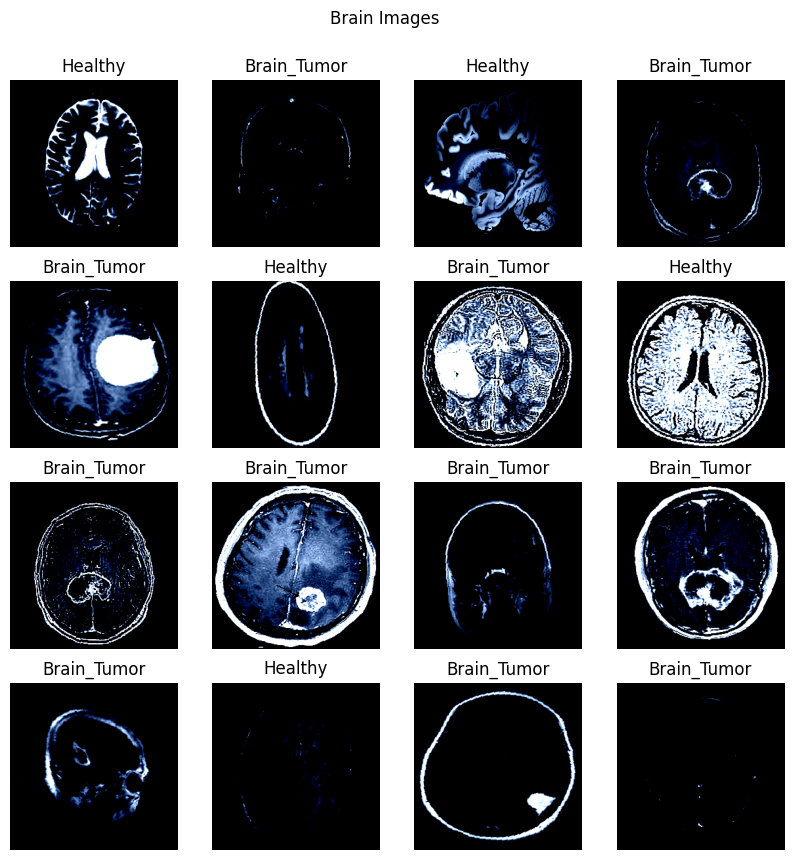

In [30]:
Class_label = {
    0 : 'Brain_Tumor',
    1 : 'Healthy'
}
figure = plt.figure(figsize=(10, 10))
cols, rows = 4, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_set), size=(1,)).item()
    img, label = train_set[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(Class_label[label])
    plt.axis("off")
    img_np = img.numpy().transpose((1, 2, 0))
    # Clip pixel values to [0, 1]
    img_valid_range = np.clip(img_np, 0, 1)
    plt.imshow(img_valid_range)
    plt.suptitle('Brain Images', y=0.95)
plt.show()

Hyperparameter Tuning with Optuna

In [31]:
#define the dynamic CNN model
class DynamicCNN(nn.Module):
    def __init__(self, num_conv_layers, num_filters, kernel_size, num_fc_layers, fc_layer_size, dropout_rate):
        super(DynamicCNN, self).__init__()
        layers = []
        in_channels = 3  #RGB images have 3 input chanel


        # Convolutional layers
        for _ in range(num_conv_layers):
            layers.append(nn.Conv2d(in_channels, num_filters, kernel_size=kernel_size, padding='same'))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm2d(num_filters))
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            in_channels = num_filters  # Update input channels for the next layer

        self.feature_extraction = nn.Sequential(*layers)

        # Fully connected layers
        fc_layers = [nn.Flatten()]
        input_size = num_filters * (256 // (2 ** num_conv_layers)) ** 2
        for _ in range(num_fc_layers):
            fc_layers.append(nn.Linear(input_size, fc_layer_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            input_size = fc_layer_size
        fc_layers.append(nn.Linear(input_size, 2))  # Final layer for 2 classes

        self.classifier = nn.Sequential(*fc_layers)

    #forward Pass
    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.classifier(x)
        return x


Defining Objective function for optuna

In [32]:
def objective(trial):
    # Hyperparameters to tune
    num_conv_layers = trial.suggest_int('num_conv_layers', 2, 4)
    num_filters = trial.suggest_categorical('num_filters', [32, 64, 128])
    kernel_size = trial.suggest_categorical('kernel_size', [3, 5])
    num_fc_layers = trial.suggest_int('num_fc_layers', 2, 3)
    fc_layer_size = trial.suggest_categorical('fc_layer_size', [64, 128, 256])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5, step=0.1)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam', 'RMSprop'])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    num_epochs = trial.suggest_int('num_epochs', 10, 30)

    # Model
    model = DynamicCNN(num_conv_layers, num_filters, kernel_size, num_fc_layers, fc_layer_size, dropout_rate).to(device)

    # Data
    train_loader = DataLoader(train_set, batch_size = batch_size, shuffle = True, num_workers = 2)
    val_loader = DataLoader(val_set, batch_size = batch_size, shuffle = False, num_workers = 2)

    # Optimizer
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

    # Validation loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_features, batch_labels in val_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = correct / total
    return accuracy

Defining Study and trails for Optuna

In [ ]:
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction='maximize', pruner=pruner)
study.optimize(objective, n_trials=10)

[I 2026-05-27 13:31:11,211] A new study created in memory with name: no-name-c8275f63-beb5-440e-9767-bac215e81152
[I 2026-05-27 13:46:03,766] Trial 0 finished with value: 0.975 and parameters: {'num_conv_layers': 3, 'num_filters': 64, 'kernel_size': 3, 'num_fc_layers': 3, 'fc_layer_size': 256, 'dropout_rate': 0.4, 'weight_decay': 4.416585667742599e-05, 'learning_rate': 0.0002934060617040028, 'optimizer': 'Adam', 'batch_size': 128, 'num_epochs': 12}. Best is trial 0 with value: 0.975.
[I 2026-05-27 13:51:49,649] Trial 1 finished with value: 0.9391304347826087 and parameters: {'num_conv_layers': 4, 'num_filters': 32, 'kernel_size': 3, 'num_fc_layers': 3, 'fc_layer_size': 128, 'dropout_rate': 0.4, 'weight_decay': 0.00032317848737838036, 'learning_rate': 0.004486754466432888, 'optimizer': 'Adam', 'batch_size': 64, 'num_epochs': 13}. Best is trial 0 with value: 0.975.
[I 2026-05-27 13:57:22,118] Trial 2 finished with value: 0.9565217391304348 and parameters: {'num_conv_layers': 3, 'num_filt

The best Hyperparameter optained with the help of Optuna

Trial 3 finished with value: 0.9836956521739131 and parameters: {'num_conv_layers': 3, 'num_filters': 128, 'kernel_size': 5, 'num_fc_layers': 2, 'fc_layer_size': 128, 'dropout_rate': 0.2, 'weight_decay': 0.00010568338162067051, 'learning_rate': 0.00016185593245298223, 'optimizer': 'Adam', 'batch_size': 64, 'num_epochs': 28}. Best is trial 3 with value: 0.9836956521739131.

Creating Data Loaders

In [33]:
train_loader = DataLoader(train_set, batch_size = 64, shuffle = True, num_workers = 2)
val_loader = DataLoader(val_set, batch_size = 64, shuffle = False, num_workers = 2)

Defining Brain Tumor Classifier





In [47]:
#Architecture on CNN model
class Brain_CNN(nn.Module):

  def __init__(self,input_features):
    super().__init__()

    #defining Convolutional Layer for feature extraction
    self.feature_extraction = nn.Sequential(
        nn.Conv2d(input_features,32,kernel_size=3,padding="same"),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(32,64,kernel_size=3,padding="same"),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(64,128,kernel_size=3,padding="same"),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    #defining clasification layer/fully connected layer
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(32*32*128,64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64,128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128,2)
    )

   #defining forward pass
  def forward(self,x):
    x=self.feature_extraction(x)
    x=self.classifier(x)
    return x

Defining Important Hyper Parameters

In [48]:
epochs=28
learning_rate=0.00016185593245298223
weight_decay=0.00010568338162067051
input_channels=3

#creating instance of CNN model
model=Brain_CNN(input_channels)

model=model.to(device)

#loss funtion
criterion=nn.CrossEntropyLoss()

#optimizer
optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)


Checking the output Size from the CNN model

In [49]:
images,labels = next(iter(train_loader))
images=images.to(device)

output = model(images)
print(output.shape)

torch.Size([64, 2])


Generating Summary of the model

In [50]:
summary(model,input_size=(64,3,256,256) )

Layer (type:depth-idx)                   Output Shape              Param #
Brain_CNN                                [64, 2]                   --
├─Sequential: 1-1                        [64, 128, 32, 32]         --
│    └─Conv2d: 2-1                       [64, 32, 256, 256]        896
│    └─ReLU: 2-2                         [64, 32, 256, 256]        --
│    └─BatchNorm2d: 2-3                  [64, 32, 256, 256]        64
│    └─MaxPool2d: 2-4                    [64, 32, 128, 128]        --
│    └─Conv2d: 2-5                       [64, 64, 128, 128]        18,496
│    └─ReLU: 2-6                         [64, 64, 128, 128]        --
│    └─BatchNorm2d: 2-7                  [64, 64, 128, 128]        128
│    └─MaxPool2d: 2-8                    [64, 64, 64, 64]          --
│    └─Conv2d: 2-9                       [64, 128, 64, 64]         73,856
│    └─ReLU: 2-10                        [64, 128, 64, 64]         --
│    └─BatchNorm2d: 2-11                 [64, 128, 64, 64]         256
│   

Defining Training and Validation loops

In [54]:
train_loss_history = []
val_loss_history = []

train_accuracy_history = []
val_accuracy_history = []

for epoch in range(epochs):

    # ==========================
    # Training Phase
    # ==========================
    model.train()

    train_loss = 0
    correct_train = 0
    total_train = 0

    for batch_features, batch_labels in train_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # Forward pass
        outputs = model(batch_features)

        # Loss
        loss = criterion(outputs, batch_labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss
        train_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, dim=1)

        total_train += batch_labels.size(0)
        correct_train += (predicted == batch_labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    # Store training history
    train_loss_history.append(avg_train_loss)
    train_accuracy_history.append(train_accuracy)

    # ==========================
    # Validation Phase
    # ==========================
    model.eval()

    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for batch_features, batch_labels in val_loader:

            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)

            loss = criterion(outputs, batch_labels)

            val_loss += loss.item()

            # Accuracy
            _, predicted = torch.max(outputs, dim=1)

            total_val += batch_labels.size(0)
            correct_val += (predicted == batch_labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val

    # Store validation history
    val_loss_history.append(avg_val_loss)
    val_accuracy_history.append(val_accuracy)

    # Epoch summary
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/28] | Train Loss: 0.0292 | Train Acc: 98.89% | Val Loss: 0.1113 | Val Acc: 98.04%
Epoch [2/28] | Train Loss: 0.0299 | Train Acc: 98.75% | Val Loss: 0.1044 | Val Acc: 98.15%
Epoch [3/28] | Train Loss: 0.0205 | Train Acc: 99.38% | Val Loss: 0.1278 | Val Acc: 97.83%
Epoch [4/28] | Train Loss: 0.0149 | Train Acc: 99.40% | Val Loss: 0.1134 | Val Acc: 97.50%
Epoch [5/28] | Train Loss: 0.0143 | Train Acc: 99.35% | Val Loss: 0.1023 | Val Acc: 97.83%
Epoch [6/28] | Train Loss: 0.0136 | Train Acc: 99.46% | Val Loss: 0.1081 | Val Acc: 98.26%
Epoch [7/28] | Train Loss: 0.0191 | Train Acc: 99.27% | Val Loss: 0.1365 | Val Acc: 97.17%
Epoch [8/28] | Train Loss: 0.0174 | Train Acc: 99.43% | Val Loss: 0.1164 | Val Acc: 97.83%
Epoch [9/28] | Train Loss: 0.0128 | Train Acc: 99.51% | Val Loss: 0.1253 | Val Acc: 97.93%
Epoch [10/28] | Train Loss: 0.0199 | Train Acc: 99.21% | Val Loss: 0.0984 | Val Acc: 98.26%
Epoch [11/28] | Train Loss: 0.0195 | Train Acc: 99.16% | Val Loss: 0.1344 | Val Acc: 96.9

Evaluation Metric Visualization

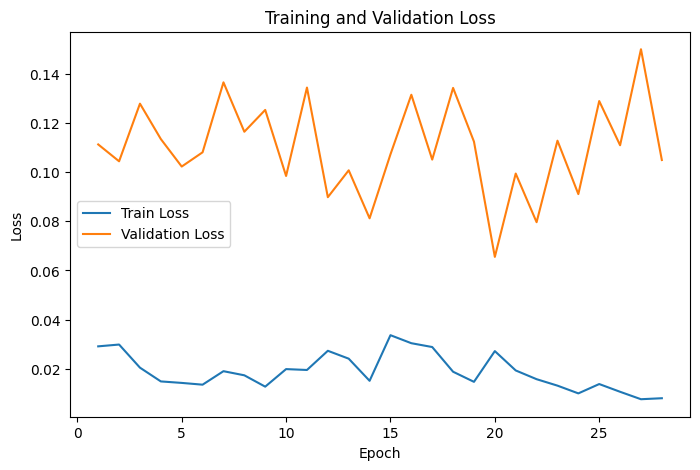

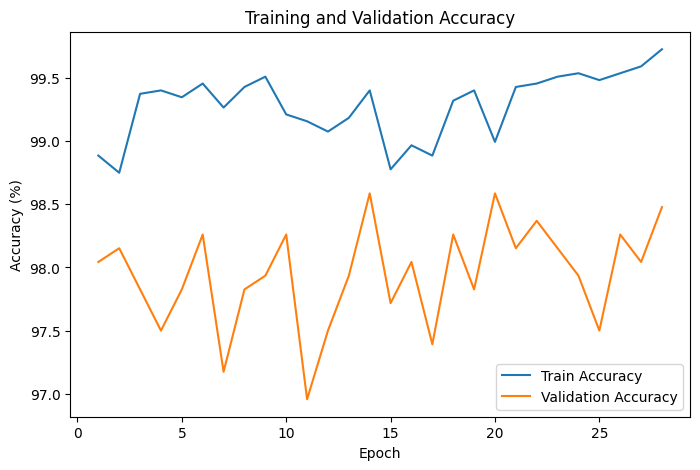

In [55]:
#Convergence History Plot
epochs_range = range(1, epochs + 1)

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss_history, label='Train Loss')
plt.plot(epochs_range, val_loss_history, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracy_history, label='Train Accuracy')
plt.plot(epochs_range, val_accuracy_history, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

Genaration of Classification Report

In [66]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch_features, batch_labels in val_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # Model predictions
        outputs = model(batch_features)

        # Predicted class
        _, predicted = torch.max(outputs, dim=1)

        # Store predictions and labels
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

# Classification Report
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_set.dataset.classes
    )
)

              precision    recall  f1-score   support

 Brain_Tumor       0.99      0.98      0.98       498
     Healthy       0.98      0.98      0.98       422

    accuracy                           0.98       920
   macro avg       0.98      0.98      0.98       920
weighted avg       0.98      0.98      0.98       920



genaration of Confusion Matrix

In [58]:
cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[487  11]
 [  6 416]]


Displaying Confusion Matrix

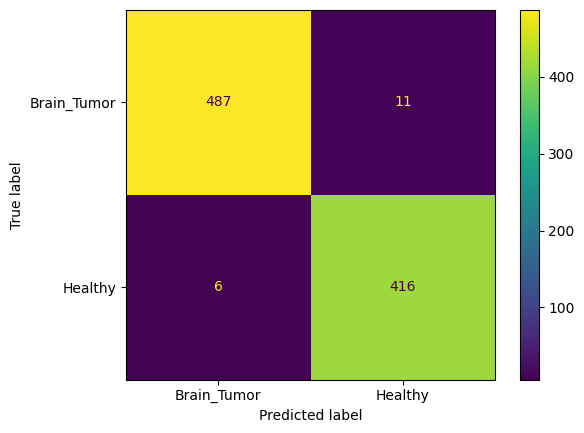

In [61]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_set.dataset.classes
)

disp.plot()
plt.show()